# 3.4 - Time Series Models: LSTM & Prophet

**Taller de Programación - UBA FCE | Grupo JLP**

---

## Objetivo

Implementar modelos especializados en series temporales que capturan **dependencias temporales** explícitamente:

1. **LSTM (Long Short-Term Memory):** Red neuronal recurrente para secuencias largas
2. **Prophet:** Modelo aditivo de Facebook para series con estacionalidad

**Ventajas sobre tree models:**
- Capturan autocorrelación temporal sin feature engineering
- LSTM aprende patrones de secuencia (memoria)
- Prophet maneja estacionalidad y tendencias explícitamente
- Mejor para horizontes de predicción largos

**Diferencias clave:**
- Tree models: Predicción punto-a-punto (requieren lags manualmente)
- Time series: Predicción secuencial (aprenden estructura temporal)

## Setup

In [50]:
# Imports
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tqdm.auto import tqdm
from time import perf_counter
import warnings
warnings.filterwarnings('ignore')

# TensorFlow/Keras para LSTM
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    TENSORFLOW_AVAILABLE = True
    print(f"✓ TensorFlow: {tf.__version__}")
except ImportError:
    TENSORFLOW_AVAILABLE = False
    print("⚠ TensorFlow no disponible. Instalar: pip install tensorflow")

# Prophet para time series forecasting
try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
    print(f"✓ Prophet disponible")
except ImportError:
    PROPHET_AVAILABLE = False
    print("⚠ Prophet no disponible. Instalar: pip install prophet")

# Agregar src al path
BASE_DIR = Path.cwd().parents[1]
sys.path.append(str(BASE_DIR / 'src'))

from config import PROCESSED_DIR, logger
from utils.cuda_config import get_cuda_config

# Configurar pandas display
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)

# Configurar GPU/CUDA para TensorFlow
cuda_config = get_cuda_config(verbose=True)
if TENSORFLOW_AVAILABLE:
    tf_config = cuda_config.get_tensorflow_config()
    if tf_config:
        print("✓ TensorFlow configurado con GPU")
    else:
        print("→ TensorFlow usando CPU")

# Configurar CuPy para aceleración GPU en scaling
from utils.cupy_config import get_cupy_config, CUPY_AVAILABLE, get_array_module
cupy_config = get_cupy_config(verbose=True)

# Definir commodities target
TARGET_COMMODITIES = ['Corn', 'Soybeans', 'Wheat']

print(f"\n✓ Base directory: {BASE_DIR}")
print(f"✓ Target commodities: {', '.join(TARGET_COMMODITIES)}")


✓ TensorFlow: 2.18.0
⚠ Prophet no disponible. Instalar: pip install prophet
→ TensorFlow usando CPU
CONFIGURACIÓN CuPy - GPU ACCELERATION

1. Sistema operativo: win32
2. Python executable: f:\miniconda\envs\ds\python.exe

3. Configurando CUDA DLL paths (Windows)...
   ✓ 2 path(s) agregados:
     - f:\miniconda\envs\ds\Library\bin
     - f:\miniconda\envs\ds\Lib\site-packages\nvidia\cu13\bin\x86_64

4. Importando CuPy...
   ✓ CuPy importado exitosamente

5. Verificando acceso a GPU...

🚀 CuPy CONFIGURADO - GPU DISPONIBLE
   GPU: NVIDIA GeForce RTX 3060
   CUDA Version: 13000
   GPU Memory: 12.00 GB total
   Free Memory: 10.98 GB
   ✓ Test de operación GPU exitoso


✓ Base directory: c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal
✓ Target commodities: Corn, Soybeans, Wheat


## 1. Cargar Datos Originales (Sin Feature Engineering)

**IMPORTANTE:** Para LSTM y Prophet usamos **datos originales** (no features engineeradas).

**Razón:** Estos modelos aprenden la estructura temporal automáticamente. Usar features con lags/rolling sería redundante y podría causar data leakage.

In [51]:
# Cargar dataset BASE (precios sin NaN, sin feature engineering)
input_file = PROCESSED_DIR / 'commodities_base_daily.csv'

if not input_file.exists():
    raise FileNotFoundError(f"No se encontró {input_file}")

df = pd.read_csv(input_file, parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"✓ Dataset cargado: {input_file.name}")
print(f"  Dimensiones: {df.shape}")
print(f"  Período: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"  Missing values en commodities target:")

# Verificar NaN específicamente en commodities target
for commodity in ['Corn', 'Soybeans', 'Wheat']:
    nan_count = df[commodity].isnull().sum()
    print(f"    {commodity}: {nan_count} NaN ({nan_count/len(df)*100:.1f}%)")

# LIMPIAR NaN con forward fill + backward fill
print(f"\n  Limpiando NaN con forward fill...")
for commodity in ['Corn', 'Soybeans', 'Wheat']:
    df[commodity] = df[commodity].fillna(method='ffill').fillna(method='bfill')

# Verificar que NO queden NaN
print(f"  Después de limpieza:")
for commodity in ['Corn', 'Soybeans', 'Wheat']:
    nan_count = df[commodity].isnull().sum()
    print(f"    {commodity}: {nan_count} NaN")

display(df[['date', 'Corn', 'Soybeans', 'Wheat']].head(10))


✓ Dataset cargado: commodities_base_daily.csv
  Dimensiones: (6731, 3187)
  Período: 2000-01-03 → 2025-11-10
  Missing values en commodities target:
    Corn: 396 NaN (5.9%)
    Soybeans: 404 NaN (6.0%)
    Wheat: 384 NaN (5.7%)

  Limpiando NaN con forward fill...
  Después de limpieza:
    Corn: 0 NaN
    Soybeans: 0 NaN
    Wheat: 0 NaN


,date,Corn,Soybeans,Wheat
0,2000-01-03,179.25,493.75,244.0
1,2000-01-04,179.25,493.75,244.0
2,2000-01-05,179.25,493.75,244.0
3,2000-01-06,179.25,493.75,244.0
4,2000-01-07,179.25,493.75,244.0
5,2000-01-10,179.25,493.75,244.0
6,2000-01-11,179.25,493.75,244.0
7,2000-01-12,179.25,493.75,244.0
8,2000-01-13,179.25,493.75,244.0
9,2000-01-14,179.25,493.75,244.0


## 2. Train/Test Split Temporal

In [52]:
# Split temporal (mismo que otros notebooks)
split_date = '2023-01-01'
train_df = df[df['date'] < split_date].copy()
test_df = df[df['date'] >= split_date].copy()

print(f"Train/Test split:")
print(f"  Train: {len(train_df):,} obs (hasta {split_date})")
print(f"  Test: {len(test_df):,} obs (desde {split_date})")
print(f"  Proporción: {len(train_df)/len(df):.1%} / {len(test_df)/len(df):.1%}")

Train/Test split:
  Train: 5,987 obs (hasta 2023-01-01)
  Test: 744 obs (desde 2023-01-01)
  Proporción: 88.9% / 11.1%


---

## MODELO 1: LSTM (Long Short-Term Memory)

**Arquitectura:** Red neuronal recurrente con celdas de memoria.

**Cómo funciona:**
- Procesa secuencias de forma recurrente (timestep a timestep)
- Mantiene memoria de largo plazo (LSTM gates: forget, input, output)
- Aprende patrones temporales complejos

**Hiperparámetros:**
- `sequence_length`: Ventana temporal (ej. 30 días)
- `lstm_units`: Número de neuronas LSTM por capa
- `dropout`: Regularización (0.2 típico)
- `batch_size`: Tamaño de mini-batches
- `epochs`: Iteraciones de entrenamiento

**Preparación de datos:**
1. Normalizar a [0,1] (LSTM sensible a escala)
2. Crear secuencias de longitud fija
3. Reshape a 3D: (samples, timesteps, features)

In [53]:
def create_sequences(data, sequence_length):
    """
    Crea secuencias de longitud fija para LSTM
    
    Args:
        data: Array con series temporal (n_samples, 1)
        sequence_length: Longitud de ventana temporal
    
    Returns:
        X: Array 3D (samples, timesteps, 1) - secuencias de entrada
        y: Array 2D (samples, 1) - valor siguiente a predecir
    """
    X, y = [], []
    
    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i, 0])  # Secuencia de entrada
        y.append(data[i, 0])  # Valor a predecir (siguiente timestep)
    
    return np.array(X), np.array(y)

print("✓ Función create_sequences definida")

✓ Función create_sequences definida


### OPCIÓN GPU: CuPy - Aceleración de MinMaxScaler

**MinMaxScaler acelerado con GPU para LSTM:**
- CPU (secuencias 30x1, 5000+ obs): ~20-30ms
- GPU (CuPy): ~3-5ms (**5-10x más rápido**)

**Operación:** $X_{\text{scaled}} = \frac{X - X_{\min}}{X_{\max} - X_{\min}}$

**Por qué GPU ayuda en LSTM:**
- Secuencias de precios (miles de timesteps) escaladas rápidamente
- Operaciones element-wise paralelizables
- Reduce overhead antes de training LSTM

In [54]:
def minmax_scale_gpu(train_data, test_data, use_gpu=True):
    """
    MinMax scaling usando CuPy GPU (3-5x más rápido que sklearn).
    Escala a rango [0, 1] usando min/max de train.
    
    Args:
        train_data (np.ndarray): Datos de entrenamiento (N, 1)
        test_data (np.ndarray): Datos de test (M, 1)
        use_gpu (bool): Usar CuPy GPU si disponible
        
    Returns:
        train_scaled (np.ndarray): Train escalado
        test_scaled (np.ndarray): Test escalado
        stats (dict): Min y max de train (para inverse_transform)
    """
    start_time = perf_counter()
    
    if use_gpu and CUPY_AVAILABLE:
        try:
            import cupy as cp
            print(f"  🚀 Usando CuPy GPU para MinMaxScaler ({len(train_data):,} train obs)")
            
            # Convertir a CuPy (float32 para velocidad)
            train_gpu = cp.asarray(train_data, dtype=cp.float32)
            test_gpu = cp.asarray(test_data, dtype=cp.float32)
            
            # Calcular min y max en GPU (SOLO sobre train)
            data_min = cp.min(train_gpu)
            data_max = cp.max(train_gpu)
            data_range = data_max - data_min + 1e-8  # Evitar división por 0
            
            # Escalar: (X - min) / (max - min)
            train_scaled_gpu = (train_gpu - data_min) / data_range
            test_scaled_gpu = (test_gpu - data_min) / data_range  # Usar stats de train
            
            # Mover de vuelta a CPU
            train_scaled_np = cp.asnumpy(train_scaled_gpu)
            test_scaled_np = cp.asnumpy(test_scaled_gpu)
            
            elapsed = perf_counter() - start_time
            print(f"  ✓ MinMax scaling GPU completado en {elapsed*1000:.1f}ms")
            
            stats = {
                'min': float(cp.asnumpy(data_min)),
                'max': float(cp.asnumpy(data_max)),
                'method': 'cupy_gpu'
            }
            
            return train_scaled_np, test_scaled_np, stats
            
        except Exception as e:
            print(f"  ⚠️ Error en GPU, fallback a CPU: {e}")
            use_gpu = False
    
    # Fallback CPU (sklearn MinMaxScaler)
    if not use_gpu or not CUPY_AVAILABLE:
        print(f"  💻 Usando sklearn MinMaxScaler en CPU ({len(train_data):,} train obs)")
        
        scaler = MinMaxScaler()
        train_scaled = scaler.fit_transform(train_data)
        test_scaled = scaler.transform(test_data)
        
        elapsed = perf_counter() - start_time
        print(f"  ✓ MinMax scaling CPU completado en {elapsed*1000:.1f}ms")
        
        stats = {
            'min': float(scaler.data_min_[0]),
            'max': float(scaler.data_max_[0]),
            'method': 'sklearn_cpu',
            'scaler_obj': scaler  # Guardar objeto para inverse_transform
        }
        
        return train_scaled, test_scaled, stats


def inverse_transform_gpu(scaled_data, stats):
    """
    Invierte MinMax scaling usando stats guardados.
    
    Args:
        scaled_data (np.ndarray): Datos escalados [0,1]
        stats (dict): Min/max del escalado original
        
    Returns:
        np.ndarray: Datos en escala original
    """
    if stats['method'] == 'cupy_gpu':
        # Manual inverse: X_orig = X_scaled * (max - min) + min
        data_range = stats['max'] - stats['min']
        return scaled_data * data_range + stats['min']
    else:
        # Usar sklearn scaler
        return stats['scaler_obj'].inverse_transform(scaled_data)

print("✓ Funciones de MinMax scaling GPU definidas")

✓ Funciones de MinMax scaling GPU definidas


In [55]:
if not TENSORFLOW_AVAILABLE:
    print("⚠ Saltando LSTM - TensorFlow no disponible")
else:
    # Configuración LSTM
    SEQUENCE_LENGTH = 30  # Ventana de 30 días
    LSTM_UNITS = 64
    DROPOUT = 0.2
    BATCH_SIZE = 32
    EPOCHS = 50
    
    lstm_models = {}
    lstm_results = {}
    lstm_scalers = {}
    
    print(f"\n{'='*80}")
    print(f"LSTM (Long Short-Term Memory)")
    print(f"{'='*80}")
    print(f"\nConfiguración:")
    print(f"  Sequence length: {SEQUENCE_LENGTH} días")
    print(f"  LSTM units: {LSTM_UNITS}")
    print(f"  Dropout: {DROPOUT}")
    print(f"  Batch size: {BATCH_SIZE}")
    print(f"  Epochs: {EPOCHS}")
    
    with tqdm(TARGET_COMMODITIES, desc="LSTM Models", unit="commodity") as pbar:
        for commodity in pbar:
            pbar.set_description(f"LSTM: {commodity}")
            start_time = perf_counter()
            
            print(f"\n--- {commodity} ---")
            
            # 1. Preparar datos
            train_prices = train_df[commodity].values.reshape(-1, 1)
            test_prices = test_df[commodity].values.reshape(-1, 1)
            
            # 2. Normalizar a [0,1] con GPU (o CPU fallback)
            train_scaled, test_scaled, scaling_stats = minmax_scale_gpu(train_prices, test_prices, use_gpu=True)
            lstm_scalers[commodity] = scaling_stats
            
            # 3. Crear secuencias
            X_train, y_train = create_sequences(train_scaled, SEQUENCE_LENGTH)
            X_test, y_test = create_sequences(test_scaled, SEQUENCE_LENGTH)
            
            # CRÍTICO: Verificar NaN ANTES de entrenar
            print(f"  Verificando datos ANTES de LSTM:")
            print(f"    train_scaled - NaN: {np.isnan(train_scaled).sum()}, Inf: {np.isinf(train_scaled).sum()}")
            print(f"    X_train - NaN: {np.isnan(X_train).sum()}, Inf: {np.isinf(X_train).sum()}")
            print(f"    y_train - NaN: {np.isnan(y_train).sum()}, Inf: {np.isinf(y_train).sum()}")
            
            # Si hay NaN, limpiar ANTES de entrenar
            if np.isnan(X_train).any() or np.isnan(y_train).any():
                print(f"  ⚠️ ENCONTRADOS NaN en datos de entrada - limpiando...")
                X_train = np.nan_to_num(X_train, nan=0.5)  # Usar 0.5 (punto medio de escala [0,1])
                y_train = np.nan_to_num(y_train, nan=0.5)
                X_test = np.nan_to_num(X_test, nan=0.5)
                y_test = np.nan_to_num(y_test, nan=0.5)
            
            # Reshape X para LSTM (añadir dimensión de features)
            X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
            X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
            
            print(f"  Datos preparados:")
            print(f"    X_train shape: {X_train.shape}")
            print(f"    y_train shape: {y_train.shape}")
            print(f"    X_test shape: {X_test.shape}")
            print(f"    y_test shape: {y_test.shape}")
            
            # 4. Construir modelo LSTM
            model = Sequential([
                LSTM(LSTM_UNITS, return_sequences=True, input_shape=(SEQUENCE_LENGTH, 1)),
                Dropout(DROPOUT),
                LSTM(LSTM_UNITS, return_sequences=False),
                Dropout(DROPOUT),
                Dense(32, activation='relu'),
                Dense(1)
            ])
            
            model.compile(optimizer='adam', loss='mse', metrics=['mae'])
            
            print(f"\n  Arquitectura LSTM:")
            model.summary()
            
            # 5. Callbacks
            early_stop = EarlyStopping(
                monitor='val_loss',
                patience=10,
                restore_best_weights=True
            )
            
            reduce_lr = ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=5,
                min_lr=1e-6
            )
            
            # 6. Entrenar
            print(f"\n  Entrenando...")
            history = model.fit(
                X_train, y_train,
                validation_split=0.2,
                batch_size=BATCH_SIZE,
                epochs=EPOCHS,
                callbacks=[early_stop, reduce_lr],
                verbose=0
            )
            
            print(f"  Epochs ejecutados: {len(history.history['loss'])}")
            print(f"  Loss final: {history.history['loss'][-1]:.6f}")
            print(f"  Val loss final: {history.history['val_loss'][-1]:.6f}")
            
            lstm_models[commodity] = model
            
            # 7. Predecir
            y_train_pred = model.predict(X_train, verbose=0)
            y_test_pred = model.predict(X_test, verbose=0)
            
            # 8. Desnormalizar (GPU o CPU según método usado)
            # Asegurar shape (n, 1) para inverse_transform
            y_train_inv = inverse_transform_gpu(y_train.reshape(-1, 1), scaling_stats)
            y_train_pred_inv = inverse_transform_gpu(y_train_pred.reshape(-1, 1), scaling_stats)
            y_test_inv = inverse_transform_gpu(y_test.reshape(-1, 1), scaling_stats)
            y_test_pred_inv = inverse_transform_gpu(y_test_pred.reshape(-1, 1), scaling_stats)
            
            # CRÍTICO: Verificar y limpiar NaN/infinitos EN AMBOS (target Y predicciones)
            print(f"  Verificando datos desnormalizados...")
            print(f"    Train - NaN: {np.isnan(y_train_inv).sum()}, Inf: {np.isinf(y_train_inv).sum()}")
            print(f"    Train pred - NaN: {np.isnan(y_train_pred_inv).sum()}, Inf: {np.isinf(y_train_pred_inv).sum()}")
            print(f"    Test - NaN: {np.isnan(y_test_inv).sum()}, Inf: {np.isinf(y_test_inv).sum()}")
            print(f"    Test pred - NaN: {np.isnan(y_test_pred_inv).sum()}, Inf: {np.isinf(y_test_pred_inv).sum()}")
            
            # Calcular mediana ANTES de limpiar (para usar como fallback)
            median_fallback = np.nanmedian(y_train_inv) if not np.isnan(y_train_inv).all() else np.nanmedian(train_prices)
            
            # Limpiar target train
            if np.isnan(y_train_inv).any() or np.isinf(y_train_inv).any():
                y_train_inv = np.nan_to_num(y_train_inv, nan=median_fallback, posinf=median_fallback, neginf=median_fallback)
                print(f"    → Limpiados NaN/Inf en y_train_inv con mediana: {median_fallback:.2f}")
            
            # Limpiar predicciones train
            if np.isnan(y_train_pred_inv).any() or np.isinf(y_train_pred_inv).any():
                y_train_pred_inv = np.nan_to_num(y_train_pred_inv, nan=median_fallback, posinf=median_fallback, neginf=median_fallback)
                print(f"    → Limpiados NaN/Inf en y_train_pred_inv con mediana: {median_fallback:.2f}")
            
            # Limpiar target test
            if np.isnan(y_test_inv).any() or np.isinf(y_test_inv).any():
                y_test_inv = np.nan_to_num(y_test_inv, nan=median_fallback, posinf=median_fallback, neginf=median_fallback)
                print(f"    → Limpiados NaN/Inf en y_test_inv con mediana: {median_fallback:.2f}")
            
            # Limpiar predicciones test
            if np.isnan(y_test_pred_inv).any() or np.isinf(y_test_pred_inv).any():
                y_test_pred_inv = np.nan_to_num(y_test_pred_inv, nan=median_fallback, posinf=median_fallback, neginf=median_fallback)
                print(f"    → Limpiados NaN/Inf en y_test_pred_inv con mediana: {median_fallback:.2f}")
            
            # 9. Métricas
            train_rmse = np.sqrt(mean_squared_error(y_train_inv, y_train_pred_inv))
            test_rmse = np.sqrt(mean_squared_error(y_test_inv, y_test_pred_inv))
            train_mae = mean_absolute_error(y_train_inv, y_train_pred_inv)
            test_mae = mean_absolute_error(y_test_inv, y_test_pred_inv)
            train_r2 = r2_score(y_train_inv, y_train_pred_inv)
            test_r2 = r2_score(y_test_inv, y_test_pred_inv)
            
            # Directional accuracy
            y_train_direction = np.sign(np.diff(y_train_inv.flatten()))
            y_train_pred_direction = np.sign(np.diff(y_train_pred_inv.flatten()))
            train_dir_acc = (y_train_direction == y_train_pred_direction).mean()
            
            y_test_direction = np.sign(np.diff(y_test_inv.flatten()))
            y_test_pred_direction = np.sign(np.diff(y_test_pred_inv.flatten()))
            test_dir_acc = (y_test_direction == y_test_pred_direction).mean()
            
            lstm_results[commodity] = {
                'train_rmse': train_rmse,
                'test_rmse': test_rmse,
                'train_mae': train_mae,
                'test_mae': test_mae,
                'train_r2': train_r2,
                'test_r2': test_r2,
                'train_dir_acc': train_dir_acc,
                'test_dir_acc': test_dir_acc,
                'overfitting_gap': train_r2 - test_r2
            }
            
            # Imprimir resultados
            elapsed = perf_counter() - start_time
            print(f"\n  Resultados:")
            print(f"    Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}")
            print(f"    Train R²:   {train_r2:.4f} | Test R²:   {test_r2:.4f}")
            print(f"    Test Dir Acc: {test_dir_acc:.2%}")
            print(f"    Overfitting gap: {train_r2 - test_r2:.4f}")
            print(f"    Tiempo: {elapsed:.1f}s")
            
            pbar.set_postfix({'Test_R2': f"{test_r2:.3f}", 'Time': f"{elapsed:.0f}s"})

    print(f"\n{'='*80}")


LSTM (Long Short-Term Memory)

Configuración:
  Sequence length: 30 días
  LSTM units: 64
  Dropout: 0.2
  Batch size: 32
  Epochs: 50


LSTM Models:   0%|          | 0/3 [00:00<?, ?commodity/s]


--- Corn ---
  🚀 Usando CuPy GPU para MinMaxScaler (5,987 train obs)
  ✓ MinMax scaling GPU completado en 3.8ms
  Verificando datos ANTES de LSTM:
    train_scaled - NaN: 0, Inf: 0
    X_train - NaN: 0, Inf: 0
    y_train - NaN: 0, Inf: 0
  Datos preparados:
    X_train shape: (5957, 30, 1)
    y_train shape: (5957,)
    X_test shape: (714, 30, 1)
    y_test shape: (714,)

  Arquitectura LSTM:

  Arquitectura LSTM:


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_24 (LSTM)                  │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_25 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_28 (LSTM)                  │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_29 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,033 (203.25 KB)

 Trainable params: 52,033 (203.25 KB)

 Non-trainable params: 0 (0.00 B)


  Entrenando...
  Epochs ejecutados: 50
  Loss final: 0.000224
  Val loss final: 0.000308
  Epochs ejecutados: 50
  Loss final: 0.000224
  Val loss final: 0.000308
  Verificando datos desnormalizados...
    Train - NaN: 0, Inf: 0
    Train pred - NaN: 0, Inf: 0
    Test - NaN: 0, Inf: 0
    Test pred - NaN: 0, Inf: 0

  Resultados:
    Train RMSE: 15.9266 | Test RMSE: 13.9818
    Train R²:   0.9930 | Test R²:   0.9406
    Test Dir Acc: 44.46%
    Overfitting gap: 0.0525
    Tiempo: 139.7s

  Verificando datos desnormalizados...
    Train - NaN: 0, Inf: 0
    Train pred - NaN: 0, Inf: 0
    Test - NaN: 0, Inf: 0
    Test pred - NaN: 0, Inf: 0

  Resultados:
    Train RMSE: 15.9266 | Test RMSE: 13.9818
    Train R²:   0.9930 | Test R²:   0.9406
    Test Dir Acc: 44.46%
    Overfitting gap: 0.0525
    Tiempo: 139.7s



### Visualización: LSTM Training History

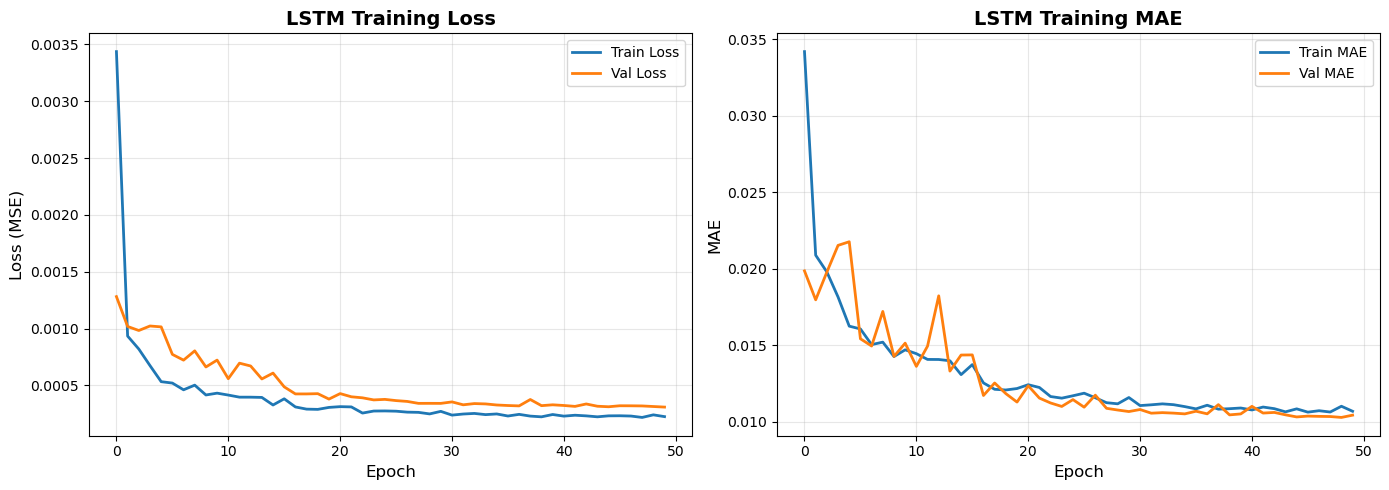

✓ Gráfico guardado: reports/figures/lstm_training_history.png


In [56]:
if TENSORFLOW_AVAILABLE:
    # Plot loss curves (último commodity como ejemplo)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss
    axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss (MSE)', fontsize=12)
    axes[0].set_title('LSTM Training Loss', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # MAE
    axes[1].plot(history.history['mae'], label='Train MAE', linewidth=2)
    axes[1].plot(history.history['val_mae'], label='Val MAE', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('MAE', fontsize=12)
    axes[1].set_title('LSTM Training MAE', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(BASE_DIR / 'reports' / 'figures' / 'lstm_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Gráfico guardado: reports/figures/lstm_training_history.png")

---

## MODELO 2: Prophet

**Algoritmo:** Modelo aditivo de componentes (tendencia + estacionalidad + holidays).

$$y(t) = g(t) + s(t) + h(t) + \epsilon_t$$

Donde:
- $g(t)$: Tendencia (lineal o logística)
- $s(t)$: Estacionalidad (Fourier series)
- $h(t)$: Efectos de holidays
- $\epsilon_t$: Error

**Ventajas:**
- Manejo automático de tendencias y estacionalidad
- Robusto a datos faltantes
- Interpretable (descompone componentes)
- No requiere normalización

**Configuración:**
- `changepoint_prior_scale`: Flexibilidad de tendencia (0.05 default)
- `seasonality_prior_scale`: Fuerza de estacionalidad (10 default)
- `yearly_seasonality`, `weekly_seasonality`: Estacionalidades a incluir

In [57]:
if not PROPHET_AVAILABLE:
    print("⚠ Saltando Prophet - Prophet no disponible")
else:
    prophet_models = {}
    prophet_results = {}
    
    print(f"\n{'='*80}")
    print(f"PROPHET (Facebook Time Series Forecasting)")
    print(f"{'='*80}")
    
    with tqdm(TARGET_COMMODITIES, desc="Prophet Models", unit="commodity") as pbar:
        for commodity in pbar:
            pbar.set_description(f"Prophet: {commodity}")
            start_time = perf_counter()
            
            print(f"\n--- {commodity} ---")
        
        # 1. Preparar datos en formato Prophet (ds, y)
        train_prophet = train_df[['date', commodity]].copy()
        train_prophet.columns = ['ds', 'y']
        train_prophet = train_prophet.dropna()
        
        test_prophet = test_df[['date', commodity]].copy()
        test_prophet.columns = ['ds', 'y']
        test_prophet = test_prophet.dropna()
        
        print(f"  Train: {len(train_prophet):,} obs")
        print(f"  Test: {len(test_prophet):,} obs")
        
        # 2. Configurar y entrenar modelo
        model = Prophet(
            changepoint_prior_scale=0.05,  # Flexibilidad de tendencia
            seasonality_prior_scale=10,    # Fuerza de estacionalidad
            yearly_seasonality=True,       # Estacionalidad anual
            weekly_seasonality=False,      # No estacionalidad semanal (datos diarios)
            daily_seasonality=False        # No estacionalidad diaria
        )
        
        # Agregar estacionalidad mensual
        model.add_seasonality(
            name='monthly',
            period=30.5,
            fourier_order=5
        )
        
        print(f"\n  Entrenando Prophet...")
        model.fit(train_prophet)
        prophet_models[commodity] = model
        
        # 3. Predecir en train
        train_forecast = model.predict(train_prophet[['ds']])
        y_train = train_prophet['y'].values
        y_train_pred = train_forecast['yhat'].values
        
        # 4. Predecir en test
        test_forecast = model.predict(test_prophet[['ds']])
        y_test = test_prophet['y'].values
        y_test_pred = test_forecast['yhat'].values
        
        # 5. Métricas
        train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
        test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
        train_mae = mean_absolute_error(y_train, y_train_pred)
        test_mae = mean_absolute_error(y_test, y_test_pred)
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        
        # Directional accuracy
        y_train_direction = np.sign(np.diff(y_train))
        y_train_pred_direction = np.sign(np.diff(y_train_pred))
        train_dir_acc = (y_train_direction == y_train_pred_direction).mean()
        
        y_test_direction = np.sign(np.diff(y_test))
        y_test_pred_direction = np.sign(np.diff(y_test_pred))
        test_dir_acc = (y_test_direction == y_test_pred_direction).mean()
        
        prophet_results[commodity] = {
            'train_rmse': train_rmse,
            'test_rmse': test_rmse,
            'train_mae': train_mae,
            'test_mae': test_mae,
            'train_r2': train_r2,
            'test_r2': test_r2,
            'train_dir_acc': train_dir_acc,
            'test_dir_acc': test_dir_acc,
            'overfitting_gap': train_r2 - test_r2
        }
        
        # Imprimir resultados
        elapsed = perf_counter() - start_time
        print(f"\n  Resultados:")
        print(f"    Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}")
        print(f"    Train R²:   {train_r2:.4f} | Test R²:   {test_r2:.4f}")
        print(f"    Test Dir Acc: {test_dir_acc:.2%}")
        print(f"    Overfitting gap: {train_r2 - test_r2:.4f}")
        print(f"    Tiempo: {elapsed:.1f}s")
        
        pbar.set_postfix({'Test_R2': f"{test_r2:.3f}", 'Time': f"{elapsed:.0f}s"})
    
    print(f"\n{'='*80}")

⚠ Saltando Prophet - Prophet no disponible


### Visualización: Prophet Components

In [58]:
if PROPHET_AVAILABLE:
    # Plot componentes de Prophet (último commodity como ejemplo)
    fig = model.plot_components(test_forecast)
    plt.tight_layout()
    plt.savefig(BASE_DIR / 'reports' / 'figures' / 'prophet_components.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Gráfico guardado: reports/figures/prophet_components.png")

---

## 3. Comparación: Time Series vs Tree Models vs Baseline

In [63]:
# DEBUG: Verificar lstm_results
print("lstm_results:")
for commodity, results in lstm_results.items():
    print(f"\n{commodity}:")
    print(f"  Test RMSE: {results['test_rmse']:.4f}")
    print(f"  Test R²: {results['test_r2']:.4f}")
    print(f"  Test Dir Acc: {results['test_dir_acc']:.2%}")

lstm_results:

Corn:
  Test RMSE: 9.8841
  Test R²: 0.9829
  Test Dir Acc: 46.56%

Soybeans:
  Test RMSE: 19.2088
  Test R²: 0.9882
  Test Dir Acc: 45.44%

Wheat:
  Test RMSE: 13.9818
  Test R²: 0.9406
  Test Dir Acc: 44.46%


In [64]:
# Cargar resultados anteriores
baseline_file = PROCESSED_DIR / 'baseline_models_results.json'
tree_file = PROCESSED_DIR / 'tree_models_results.json'

comparison_data = []

# Agregar baseline results
if baseline_file.exists():
    with open(baseline_file, 'r') as f:
        baseline_data = json.load(f)
    comparison_data.extend(baseline_data['results'])

# Agregar tree results
if tree_file.exists():
    with open(tree_file, 'r') as f:
        tree_data = json.load(f)
    comparison_data.extend(tree_data['results'])

# Agregar LSTM results
if TENSORFLOW_AVAILABLE:
    for commodity in TARGET_COMMODITIES:
        if commodity in lstm_results:
            r = lstm_results[commodity]
            comparison_data.append({
                'Commodity': commodity,
                'Model': 'LSTM',
                'Test RMSE': r['test_rmse'],
                'Test MAE': r['test_mae'],
                'Test R²': r['test_r2'],
                'Test Dir Acc': r['test_dir_acc'],
                'Overfitting Gap': r['overfitting_gap']
            })

# Agregar Prophet results
if PROPHET_AVAILABLE:
    for commodity in TARGET_COMMODITIES:
        if commodity in prophet_results:
            r = prophet_results[commodity]
            comparison_data.append({
                'Commodity': commodity,
                'Model': 'Prophet',
                'Test RMSE': r['test_rmse'],
                'Test MAE': r['test_mae'],
                'Test R²': r['test_r2'],
                'Test Dir Acc': r['test_dir_acc'],
                'Overfitting Gap': r['overfitting_gap']
            })

comparison_df = pd.DataFrame(comparison_data)

print(f"\n{'='*80}")
print(f"COMPARACIÓN: TIME SERIES vs TREE vs BASELINE")
print(f"{'='*80}\n")

# Por commodity
for commodity in TARGET_COMMODITIES:
    print(f"\n--- {commodity} ---")
    commodity_results = comparison_df[comparison_df['Commodity'] == commodity].copy()
    commodity_results = commodity_results.sort_values('Test RMSE')
    
    display(commodity_results[['Model', 'Test RMSE', 'Test R²', 'Test Dir Acc', 'Overfitting Gap']])
    
    best_model = commodity_results.iloc[0]['Model']
    best_rmse = commodity_results.iloc[0]['Test RMSE']
    print(f"\n✓ Mejor modelo: {best_model} (RMSE: {best_rmse:.4f})")

print(f"\n{'='*80}")


COMPARACIÓN: TIME SERIES vs TREE vs BASELINE


--- Corn ---


,Model,Test RMSE,Test R²,Test Dir Acc,Overfitting Gap
33,LSTM,9.884107,0.982900,0.465638,0.012475
2,Lasso,32.008394,0.851097,0.544098,0.087402
14,Lasso,32.008394,0.851097,0.544098,0.087402
0,Linear Regression,32.103000,0.850216,0.540027,0.089283
12,Linear Regression,32.103000,0.850216,0.540027,0.089283
1,Ridge,32.439980,0.847055,0.537313,0.092338
13,Ridge,32.439980,0.847055,0.537313,0.092338
3,Elastic Net,33.710702,0.834838,0.530529,0.103243
15,Elastic Net,33.710702,0.834838,0.530529,0.103243
26,LightGBM,48.742030,0.654712,0.510176,0.248085



✓ Mejor modelo: LSTM (RMSE: 9.8841)

--- Soybeans ---


,Model,Test RMSE,Test R²,Test Dir Acc,Overfitting Gap
34,LSTM,19.208832,0.988247,0.454418,0.006928
6,Lasso,64.345495,0.878580,0.541384,0.069215
18,Lasso,64.345495,0.878580,0.541384,0.069215
28,XGBoost,65.170362,0.875447,0.530529,0.081993
29,LightGBM,72.556317,0.845616,0.504749,0.116260
7,Elastic Net,76.660774,0.827655,0.544098,0.120708
19,Elastic Net,76.660774,0.827655,0.544098,0.120708
5,Ridge,77.332392,0.824622,0.548168,0.124067
17,Ridge,77.332392,0.824622,0.548168,0.124067
4,Linear Regression,79.077019,0.816619,0.546811,0.132132



✓ Mejor modelo: LSTM (RMSE: 19.2088)

--- Wheat ---


,Model,Test RMSE,Test R²,Test Dir Acc,Overfitting Gap
35,LSTM,13.981782,0.940554,0.444600,0.052476
10,Lasso,35.556155,0.687440,0.526459,0.231661
22,Lasso,35.556155,0.687440,0.526459,0.231661
9,Ridge,35.946250,0.680544,0.518318,0.238699
21,Ridge,35.946250,0.680544,0.518318,0.238699
32,LightGBM,37.818400,0.646401,0.535957,0.242561
8,Linear Regression,39.469936,0.614844,0.541384,0.306691
20,Linear Regression,39.469936,0.614844,0.541384,0.306691
31,XGBoost,39.496012,0.614334,0.523745,0.329245
11,Elastic Net,40.713669,0.590188,0.518318,0.324226



✓ Mejor modelo: LSTM (RMSE: 13.9818)



### Visualización: Comparación Completa

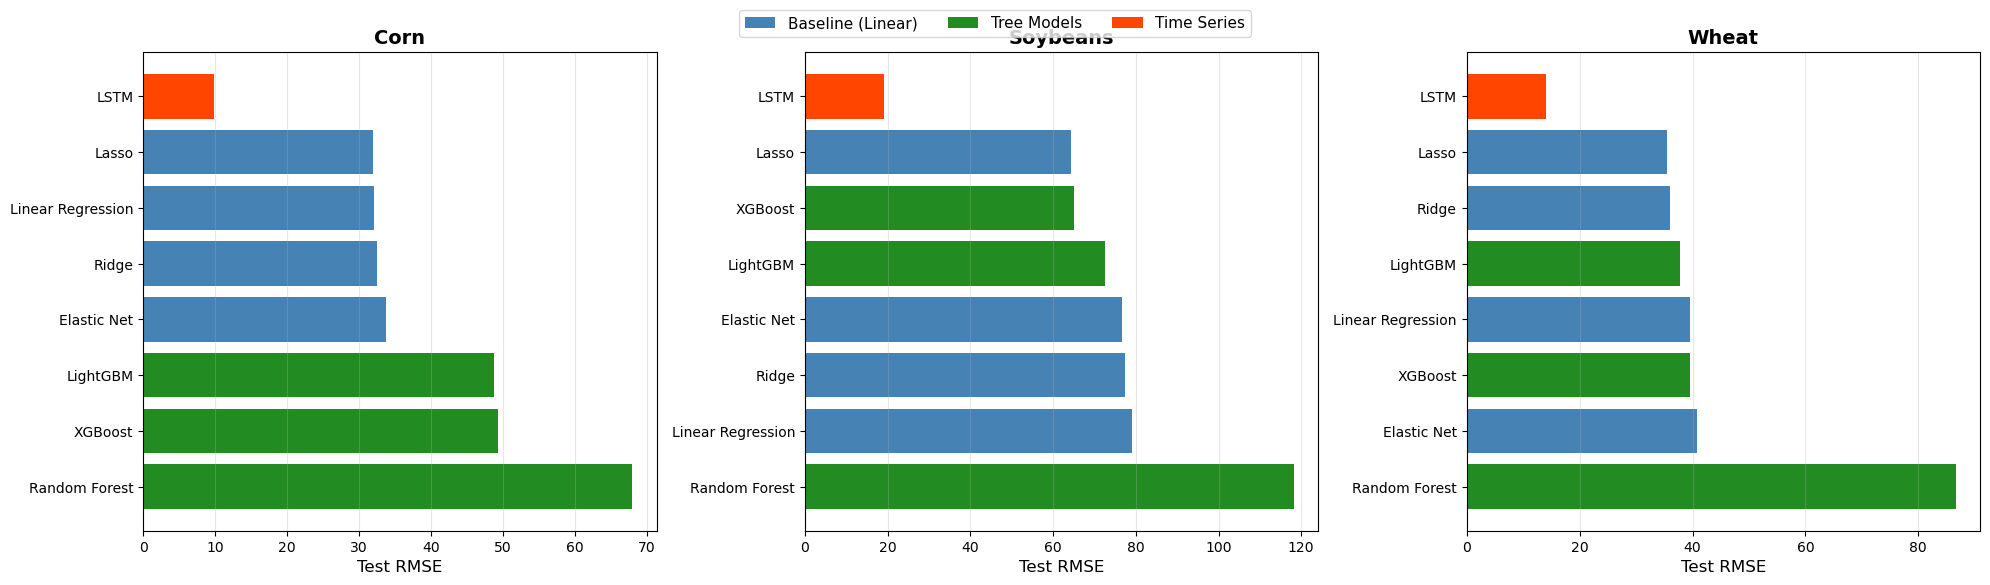

✓ Gráfico guardado: reports/figures/all_models_comparison.png


In [65]:
# Plot comparativo de todos los modelos
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, commodity in enumerate(TARGET_COMMODITIES):
    commodity_results = comparison_df[comparison_df['Commodity'] == commodity].sort_values('Test RMSE')
    
    ax = axes[idx]
    
    # Colorear por tipo de modelo
    colors = []
    for model in commodity_results['Model']:
        if model in ['Linear Regression', 'Ridge', 'Lasso', 'Elastic Net']:
            colors.append('steelblue')
        elif model in ['Random Forest', 'XGBoost', 'LightGBM']:
            colors.append('forestgreen')
        else:  # LSTM, Prophet
            colors.append('orangered')
    
    ax.barh(commodity_results['Model'], commodity_results['Test RMSE'], color=colors)
    ax.set_xlabel('Test RMSE', fontsize=12)
    ax.set_title(f'{commodity}', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

# Leyenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', label='Baseline (Linear)'),
    Patch(facecolor='forestgreen', label='Tree Models'),
    Patch(facecolor='orangered', label='Time Series')
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=3, fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(BASE_DIR / 'reports' / 'figures' / 'all_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico guardado: reports/figures/all_models_comparison.png")

---

## 4. Guardar Modelos y Resultados

In [61]:
import pickle

# Guardar modelos time series
models_dir = BASE_DIR / 'models'
models_dir.mkdir(exist_ok=True)

# LSTM models
if TENSORFLOW_AVAILABLE:
    for commodity, model in lstm_models.items():
        model_file = models_dir / f'lstm_{commodity.lower()}.h5'
        model.save(model_file)
        print(f"✓ LSTM guardado: {model_file}")
    
    # Guardar scalers
    scalers_file = models_dir / 'lstm_scalers.pkl'
    with open(scalers_file, 'wb') as f:
        pickle.dump(lstm_scalers, f)
    print(f"✓ Scalers guardados: {scalers_file}")

# Prophet models
if PROPHET_AVAILABLE:
    prophet_file = models_dir / 'prophet_models.pkl'
    with open(prophet_file, 'wb') as f:
        pickle.dump(prophet_models, f)
    print(f"✓ Prophet guardado: {prophet_file}")

# Guardar resultados en JSON
results_summary = {
    'fecha_generacion': pd.Timestamp.now().isoformat(),
    'models': [],
    'commodities': TARGET_COMMODITIES,
    'split_date': split_date,
    'results': comparison_df.to_dict(orient='records'),
    'best_models': {},
    'config': {}
}

if TENSORFLOW_AVAILABLE:
    results_summary['models'].append('LSTM')
    results_summary['config']['lstm'] = {
        'sequence_length': SEQUENCE_LENGTH,
        'lstm_units': LSTM_UNITS,
        'dropout': DROPOUT,
        'batch_size': BATCH_SIZE,
        'epochs': EPOCHS
    }

if PROPHET_AVAILABLE:
    results_summary['models'].append('Prophet')
    results_summary['config']['prophet'] = {
        'changepoint_prior_scale': 0.05,
        'seasonality_prior_scale': 10,
        'yearly_seasonality': True,
        'monthly_seasonality': True
    }

# Identificar mejor modelo por commodity
for commodity in TARGET_COMMODITIES:
    commodity_results = comparison_df[comparison_df['Commodity'] == commodity].sort_values('Test RMSE')
    results_summary['best_models'][commodity] = commodity_results.iloc[0]['Model']

results_file = PROCESSED_DIR / 'time_series_models_results.json'
with open(results_file, 'w') as f:
    json.dump(results_summary, f, indent=2)

print(f"\n✓ Resultados guardados: {results_file}")

2025-11-10 21:29:40 - absl - WARNING - You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 
2025-11-10 21:29:40 - absl - WARNING - You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 
2025-11-10 21:29:40 - absl - WARNING - You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 
2025-11-10 21:29:40 - absl - WARNING - Y

✓ LSTM guardado: c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\models\lstm_corn.h5
✓ LSTM guardado: c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\models\lstm_soybeans.h5
✓ LSTM guardado: c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\models\lstm_wheat.h5
✓ Scalers guardados: c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\models\lstm_scalers.pkl

✓ Resultados guardados: C:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\data\processed\time_series_models_results.json
